In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [3]:
high = pd.read_csv('high_popularity_spotify_data.csv')
low  = pd.read_csv('low_popularity_spotify_data.csv')

df = pd.concat([high, low], ignore_index=True)

print("Shape:", df.shape)
print(df[['track_name','track_artist','track_popularity','danceability','energy']].head())

Shape: (4831, 29)
           track_name           track_artist  track_popularity  danceability  \
0    Die With A Smile  Lady Gaga, Bruno Mars               100         0.521   
1  BIRDS OF A FEATHER          Billie Eilish                97         0.747   
2      That’s So True          Gracie Abrams                93         0.554   
3               Taste      Sabrina Carpenter                81         0.670   
4                APT.       ROSÉ, Bruno Mars                98         0.777   

   energy  
0   0.592  
1   0.507  
2   0.808  
3   0.910  
4   0.783  


In [4]:
df.drop_duplicates(subset='track_name', inplace=True)
df.dropna(subset=['track_artist','track_popularity','danceability','energy'], inplace=True)

df['year'] = pd.to_datetime(df['track_album_release_date'], errors='coerce').dt.year

print("Clean shape:", df.shape)

Clean shape: (4371, 30)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11796\1570894241.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='Greens_r')


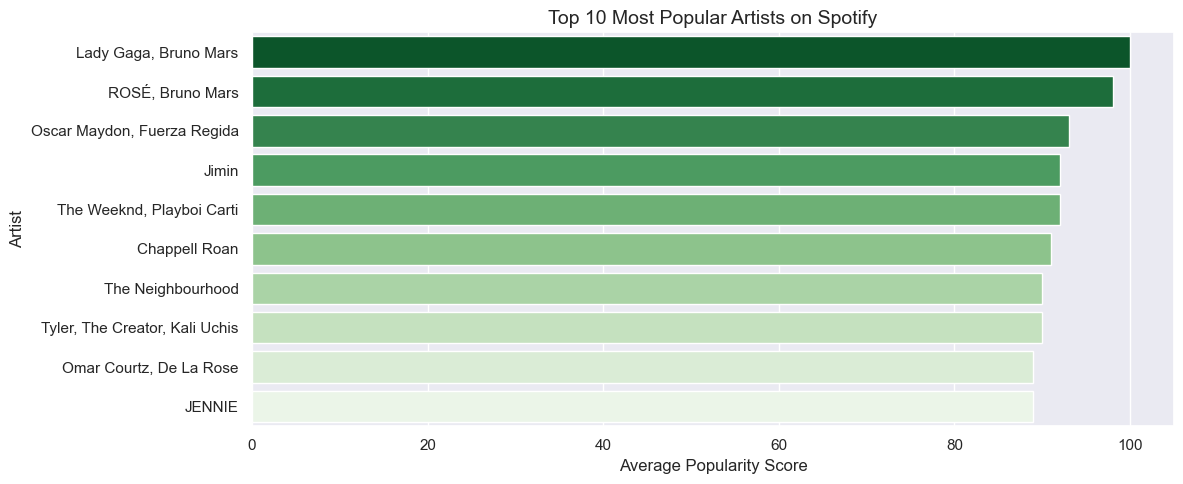

In [5]:
top_artists = (
    df.groupby('track_artist')['track_popularity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_artists.values, y=top_artists.index, palette='Greens_r')
plt.title('Top 10 Most Popular Artists on Spotify', fontsize=14)
plt.xlabel('Average Popularity Score')
plt.ylabel('Artist')
plt.tight_layout()
plt.savefig('most_popular_artists.png', dpi=150)

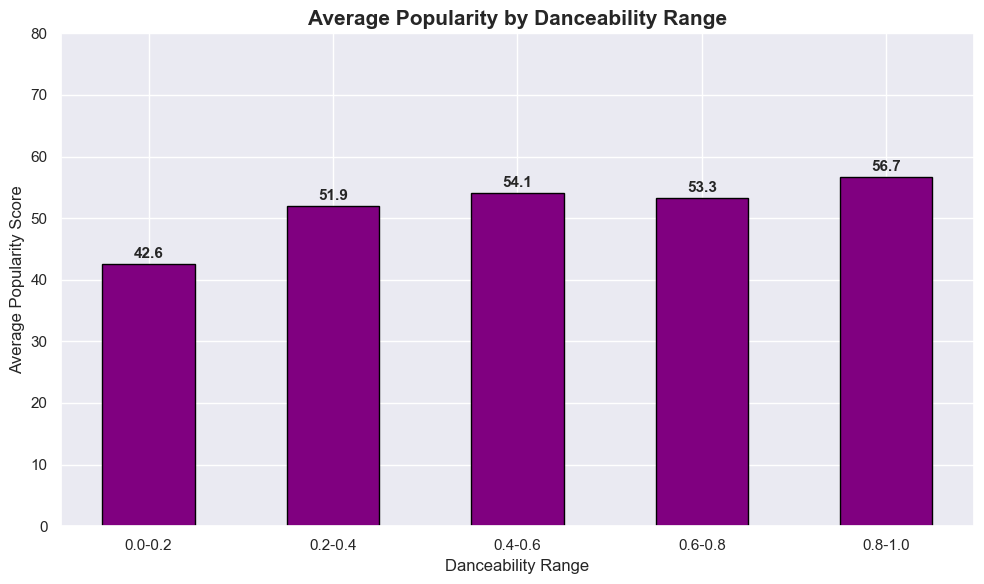

In [6]:
df['dance_group'] = pd.cut(df['danceability'], 
                            bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                            labels=['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

avg_popularity = df.groupby('dance_group', observed=True)['track_popularity'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(avg_popularity.index, avg_popularity.values, color='purple', edgecolor='black', width=0.5)

# Add value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.5, 
             f'{bar.get_height():.1f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Average Popularity by Danceability Range', fontsize=15, fontweight='bold')
plt.xlabel('Danceability Range', fontsize=12)
plt.ylabel('Average Popularity Score', fontsize=12)
plt.ylim(0, 80)
plt.tight_layout()
plt.savefig('danceability_vs_popularity.png', dpi=150)
plt.show()

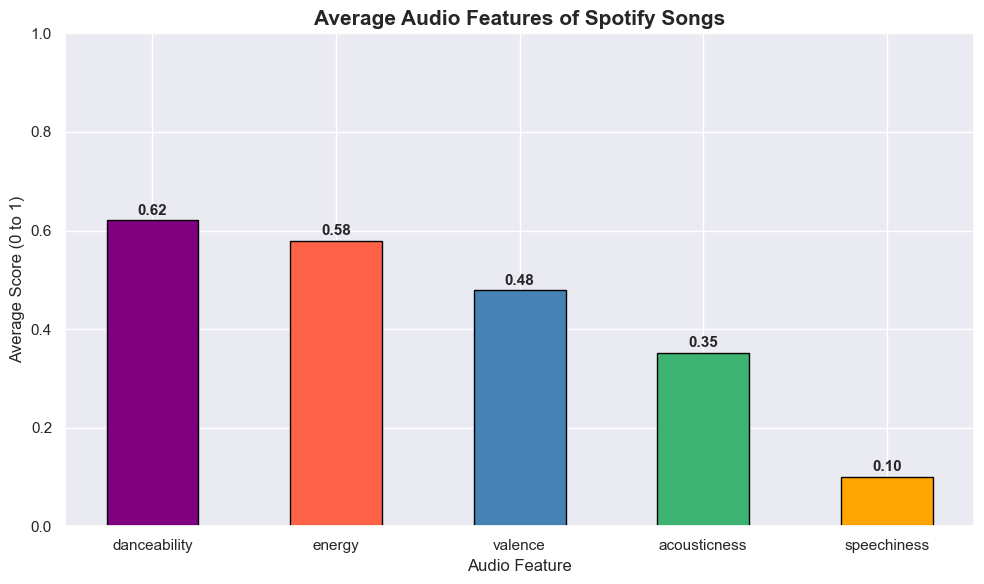

In [12]:
features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']

avg_features = df[features].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(avg_features.index, avg_features.values, 
               color=['purple', 'tomato', 'steelblue', 'mediumseagreen', 'orange'],
               edgecolor='black', width=0.5)

# Value labels on top
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Average Audio Features of Spotify Songs', fontsize=15, fontweight='bold')
plt.xlabel('Audio Feature', fontsize=12)
plt.ylabel('Average Score (0 to 1)', fontsize=12)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('audio_features_trend.png', dpi=150)
plt.show()

In [8]:
top5_songs = (
    df[['track_name', 'track_artist', 'track_popularity']]
    .sort_values('track_popularity', ascending=False)
    .drop_duplicates('track_name')
    .head(5)
    .reset_index(drop=True)
)

top5_songs.index += 1
print("\n🎵 Top 5 Songs:\n", top5_songs.to_string())


🎵 Top 5 Songs:
            track_name                 track_artist  track_popularity
1    Die With A Smile        Lady Gaga, Bruno Mars               100
2                APT.             ROSÉ, Bruno Mars                98
3  BIRDS OF A FEATHER                Billie Eilish                97
4    Good Luck, Babe!                Chappell Roan                94
5             Tu Boda  Oscar Maydon, Fuerza Regida                93


In [9]:
top5_artists = (
    df.groupby('track_artist')['track_popularity']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

top5_artists.columns = ['Artist', 'Avg Popularity']
top5_artists.index += 1
print("\n🎤 Top 5 Artists:\n", top5_artists.to_string())


🎤 Top 5 Artists:
                         Artist  Avg Popularity
1        Lady Gaga, Bruno Mars           100.0
2             ROSÉ, Bruno Mars            98.0
3  Oscar Maydon, Fuerza Regida            93.0
4                        Jimin            92.0
5    The Weeknd, Playboi Carti            92.0


In [10]:
top5_energy = (
    df[['track_name', 'track_artist', 'energy']]
    .sort_values('energy', ascending=False)
    .drop_duplicates('track_name')
    .head(5)
    .reset_index(drop=True)
)

top5_energy.index += 1
print("Top 5 Energetic Songs:\n", top5_energy.to_string())

Top 5 Energetic Songs:
                                              track_name                            track_artist  energy
1                                             Hard Beat  TNT, Darren Styles, Technoboy, Tuneboy   0.998
2                                        Wait and Bleed                                Slipknot   0.996
3                                           Wanna Play?                             The Prophet   0.996
4  Open Sesame (Abracadabra) - D-Block & S-te-Fan Remix     Maddix, Leila K, D-Block & S-te-Fan   0.995
5                                         Hit The Floor                  Bloodlust, Holy Priest   0.993


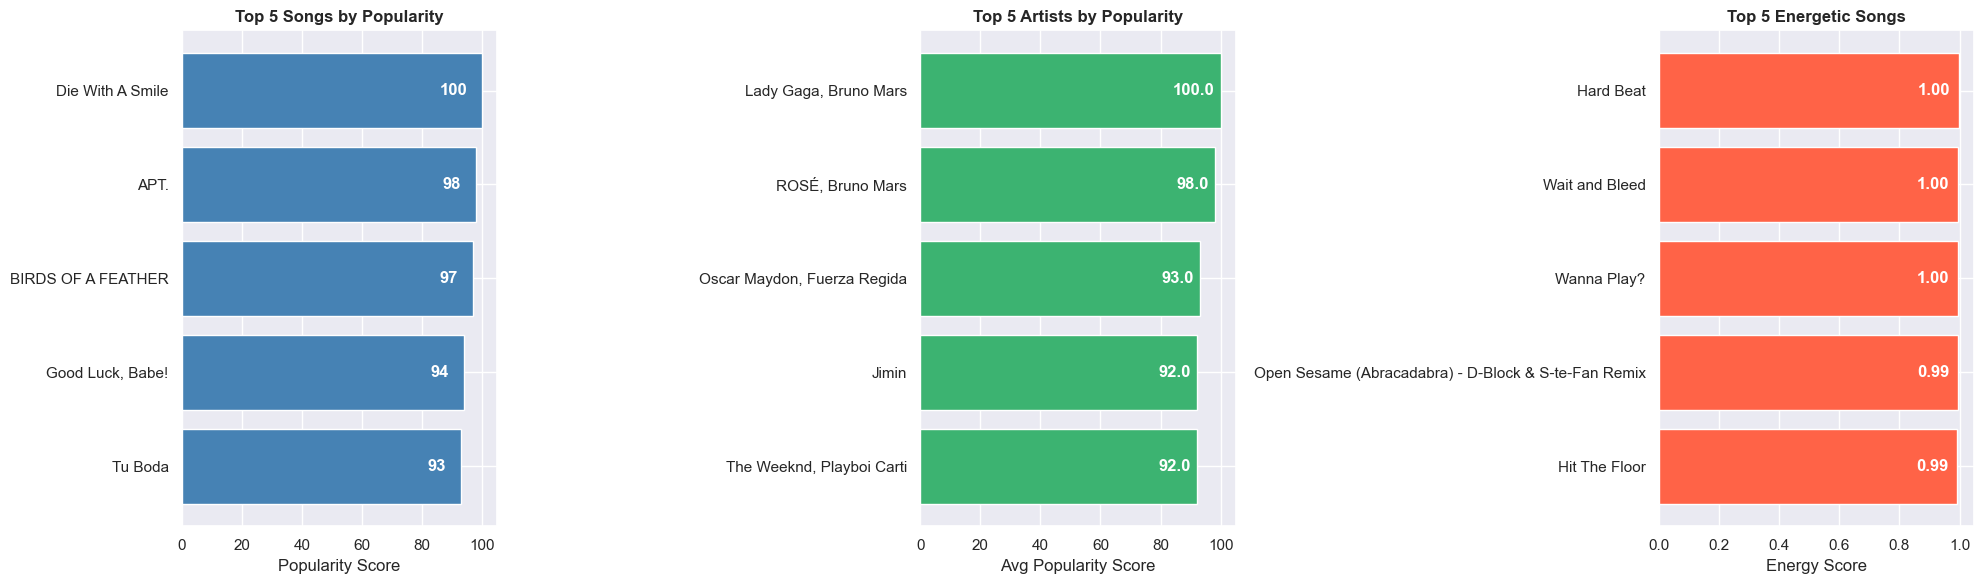

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Top 5 Songs
bars1 = axes[0].barh(top5_songs['track_name'], top5_songs['track_popularity'], color='steelblue')
axes[0].set_title('Top 5 Songs by Popularity', fontweight='bold')
axes[0].set_xlabel('Popularity Score')
axes[0].invert_yaxis()
for bar in bars1:
    axes[0].text(bar.get_width() - 5, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.0f}', va='center', ha='right', 
                 color='white', fontweight='bold')

# Top 5 Artists
bars2 = axes[1].barh(top5_artists['Artist'], top5_artists['Avg Popularity'], color='mediumseagreen')
axes[1].set_title('Top 5 Artists by Popularity', fontweight='bold')
axes[1].set_xlabel('Avg Popularity Score')
axes[1].invert_yaxis()
for bar in bars2:
    axes[1].text(bar.get_width() - 2, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}', va='center', ha='right',
                 color='white', fontweight='bold')

# Top 5 Energetic Songs
bars3 = axes[2].barh(top5_energy['track_name'], top5_energy['energy'], color='tomato')
axes[2].set_title('Top 5 Energetic Songs', fontweight='bold')
axes[2].set_xlabel('Energy Score')
axes[2].invert_yaxis()
for bar in bars3:
    axes[2].text(bar.get_width() - 0.03, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.2f}', va='center', ha='right',
                 color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('top5_summary.png', dpi=150, bbox_inches='tight')
plt.show()